In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# load the dataset
df = pd.read_csv('../data/raw/creditcard.csv')
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [3]:
df.shape

(284807, 31)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [5]:
missing = df.isnull().sum()
print(missing[missing > 0])

Series([], dtype: int64)


In [6]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


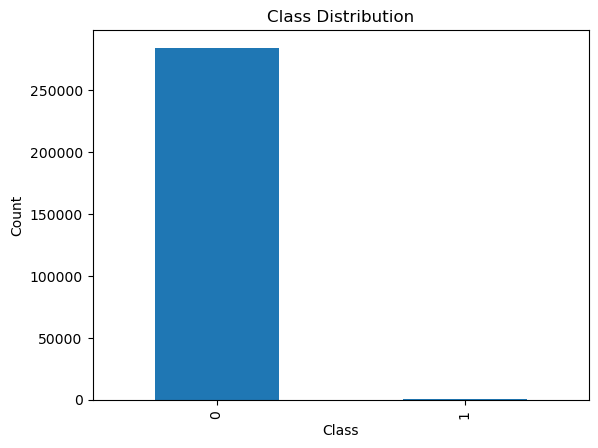

In [7]:
class_counts = df['Class'].value_counts()
class_counts.plot(kind='bar')
plt.title('Class Distribution')
plt.xlabel('Class')
plt.ylabel('Count')
plt.show()

In [8]:
class_counts

Class
0    284315
1       492
Name: count, dtype: int64

In [9]:
class_percentage = (class_counts / len(df) * 100).round(2).astype(str) + '%'
class_percentage

Class
0    99.83%
1     0.17%
Name: count, dtype: object

In [10]:
fraud = df[df['Class'] == 1]
non_fraud = df[df['Class'] == 0]
print(f'Fraudulent transactions: {len(fraud)}')
print(f'Legitimate transactions: {len(non_fraud)}')


Fraudulent transactions: 492
Legitimate transactions: 284315


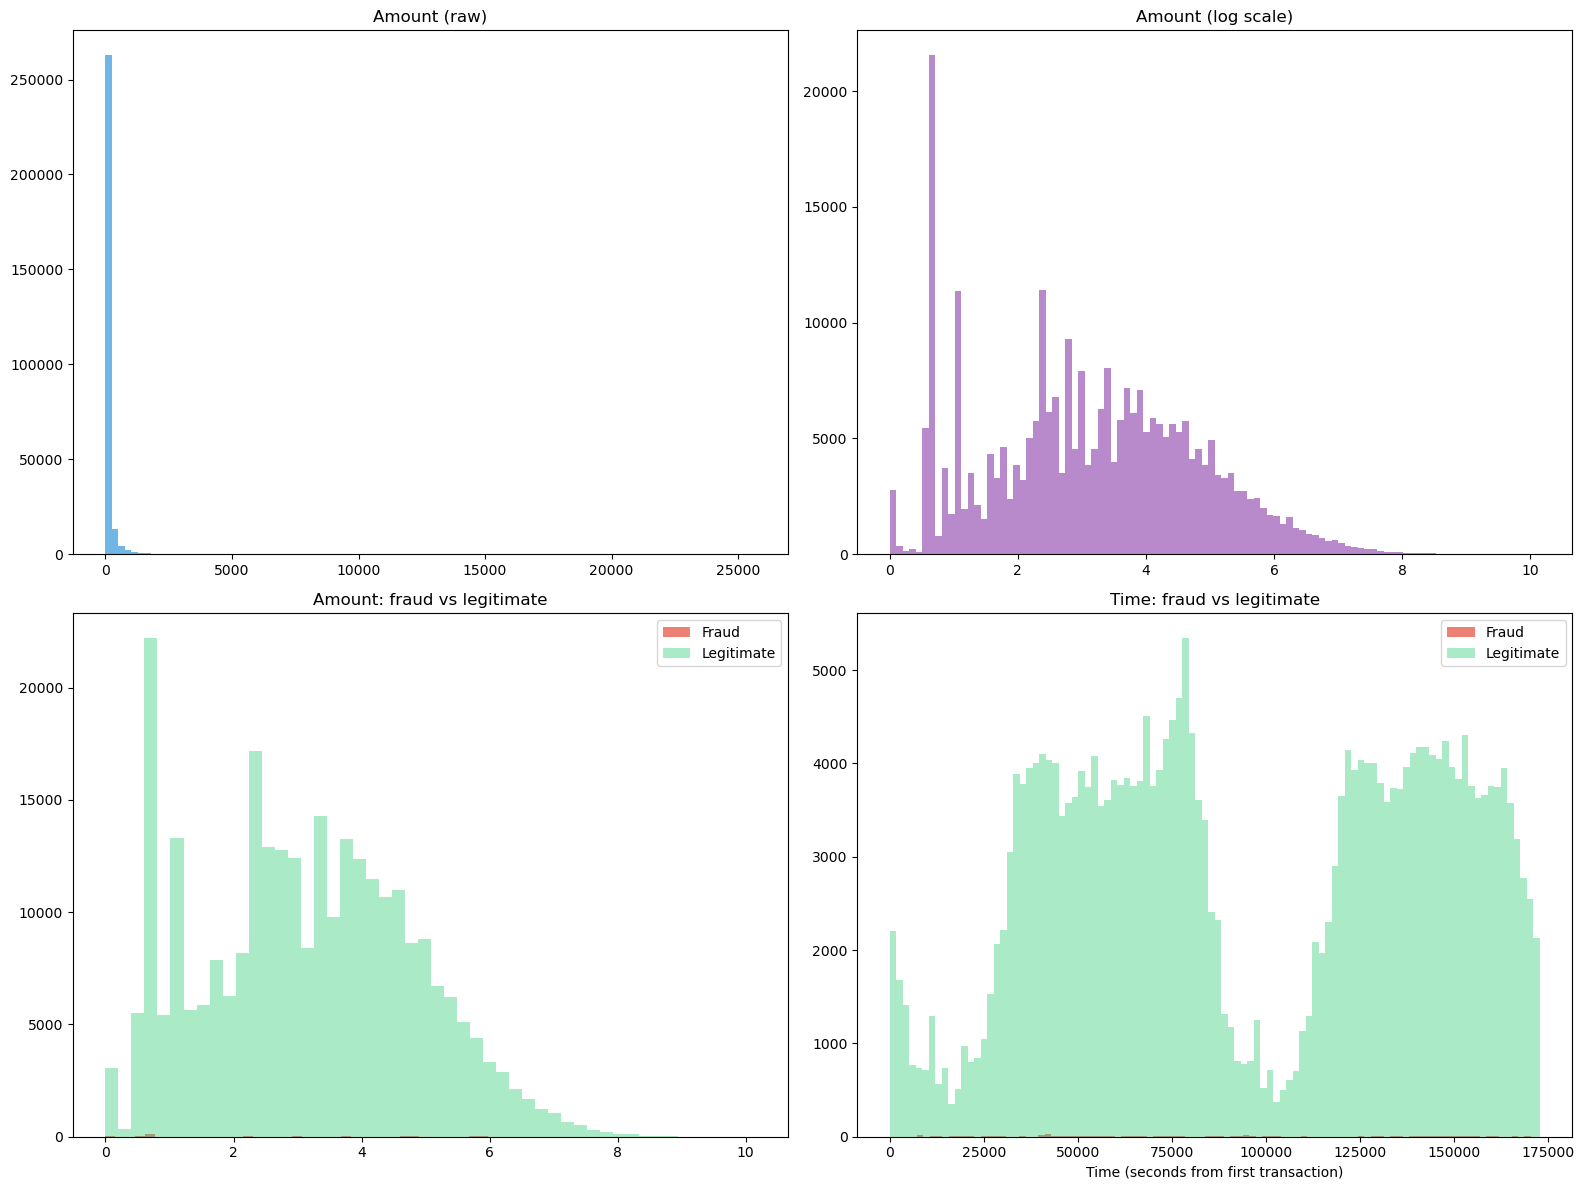

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

axes[0, 0].hist(df['Amount'], bins=100, color='#3498db', alpha=0.7)
axes[0, 0].set_title('Amount (raw)')

axes[0, 1].hist(np.log1p(df['Amount']), bins=100, color='#9b59b6', alpha=0.7)
axes[0, 1].set_title('Amount (log scale)')

fraud_amounts = df[df['Class'] == 1]['Amount']
legit_amounts = df[df['Class'] == 0]['Amount']

axes[1, 0].hist(np.log1p(fraud_amounts), bins=50,
                color='#e74c3c', alpha=0.7, label='Fraud')
axes[1, 0].hist(np.log1p(legit_amounts), bins=50,
                color='#2ecc71', alpha=0.4, label='Legitimate')
axes[1, 0].set_title('Amount: fraud vs legitimate')
axes[1, 0].legend()

fraud_times = df[df['Class'] == 1]['Time']
legit_times = df[df['Class'] == 0]['Time']

axes[1, 1].hist(fraud_times, bins=100, color='#e74c3c', alpha=0.7, label='Fraud')
axes[1, 1].hist(legit_times, bins=100, color='#2ecc71', alpha=0.4, label='Legitimate')
axes[1, 1].set_title('Time: fraud vs legitimate')   
axes[1, 1].set_xlabel('Time (seconds from first transaction)')
axes[1, 1].legend()

plt.tight_layout()
plt.show()


In [23]:
df['Hour'] = (df['Time'] // 3600) % 24

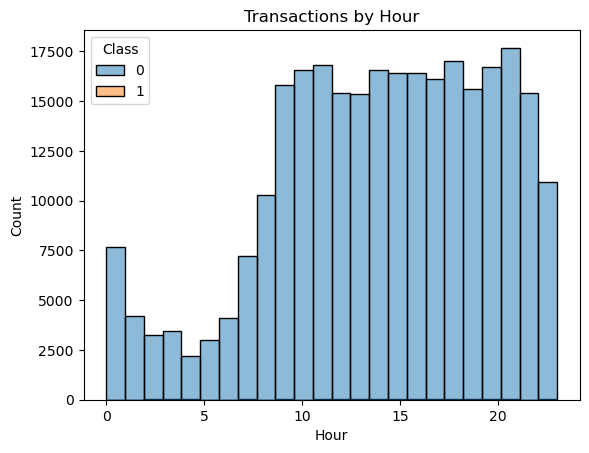

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(data=df, x='Hour', hue='Class', bins=24)
plt.title('Transactions by Hour')
plt.show()

In [12]:
print(df.groupby('Class')['Amount'].describe())

          count        mean         std  min   25%    50%     75%       max
Class                                                                      
0      284315.0   88.291022  250.105092  0.0  5.65  22.00   77.05  25691.16
1         492.0  122.211321  256.683288  0.0  1.00   9.25  105.89   2125.87


In [13]:
# the mean difference
v_features = [f'V{i}' for i in range(1, 29)]
v_means = df.groupby('Class')[v_features].mean()
v_means


,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28
Class,,,,,,,,,,,,,,,,,,,,,
0,0.008258,-0.006271,0.012171,-0.007860,0.005453,0.002419,0.009637,-0.000987,0.004467,0.009824,...,-0.001178,-0.000644,-0.001235,-0.000024,0.000070,0.000182,-0.000072,-0.000089,-0.000295,-0.000131
1,-4.771948,3.623778,-7.033281,4.542029,-3.151225,-1.397737,-5.568731,0.570636,-2.581123,-5.676883,...,0.680659,0.372319,0.713588,0.014049,-0.040308,-0.105130,0.041449,0.051648,0.170575,0.075667


In [14]:
fraud_means = df[df['Class'] == 1][v_features].mean()
legit_means = df[df['Class'] == 0][v_features].mean()

comparison = pd.DataFrame({'Fraud': fraud_means, 'Legitimate': legit_means})
comparison['Difference'] = comparison['Fraud'] - comparison['Legitimate']
comparison['Abs Difference'] = comparison['Difference'].abs()
comparison.sort_values('Abs Difference', ascending=False)

top_values = comparison.sort_values('Abs Difference', ascending=False).head(10)
top_values

,Fraud,Legitimate,Difference,Abs Difference
V3,-7.033281,0.012171,-7.045452,7.045452
V14,-6.971723,0.012064,-6.983787,6.983787
V17,-6.665836,0.011535,-6.677371,6.677371
V12,-6.259393,0.010832,-6.270225,6.270225
V10,-5.676883,0.009824,-5.686707,5.686707
V7,-5.568731,0.009637,-5.578368,5.578368
V1,-4.771948,0.008258,-4.780206,4.780206
V4,4.542029,-0.007860,4.549889,4.549889
V16,-4.139946,0.007164,-4.147110,4.147110
V11,3.800173,-0.006576,3.806749,3.806749


In [15]:
df.corr(numeric_only=True)['Class'].abs().sort_values(ascending=False).head(10)

Class    1.000000
V17      0.326481
V14      0.302544
V12      0.260593
V10      0.216883
V16      0.196539
V3       0.192961
V7       0.187257
V11      0.154876
V4       0.133447
Name: Class, dtype: float64

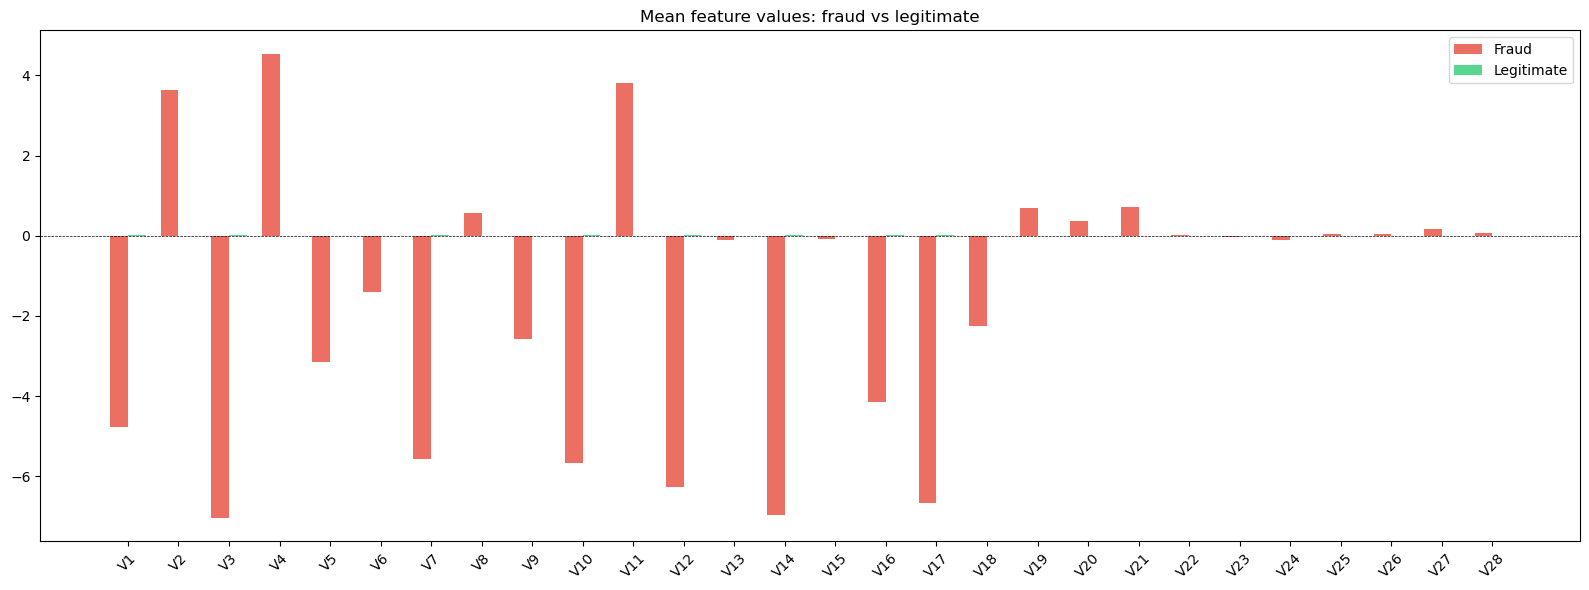

In [16]:
fig, ax = plt.subplots(figsize=(16, 6))
x = np.arange(len(v_features))
width = 0.35 
ax.bar(x - width/2, fraud_means, width,
       label='Fraud', color='#e74c3c', alpha=0.8)
ax.bar(x + width/2, legit_means, width,
       label='Legitimate', color='#2ecc71', alpha=0.8)
 
ax.set_xticks(x)
ax.set_xticklabels(v_features, rotation=45)
ax.set_title('Mean feature values: fraud vs legitimate')
ax.legend()

ax.axhline(y=0, color='black', linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.show()

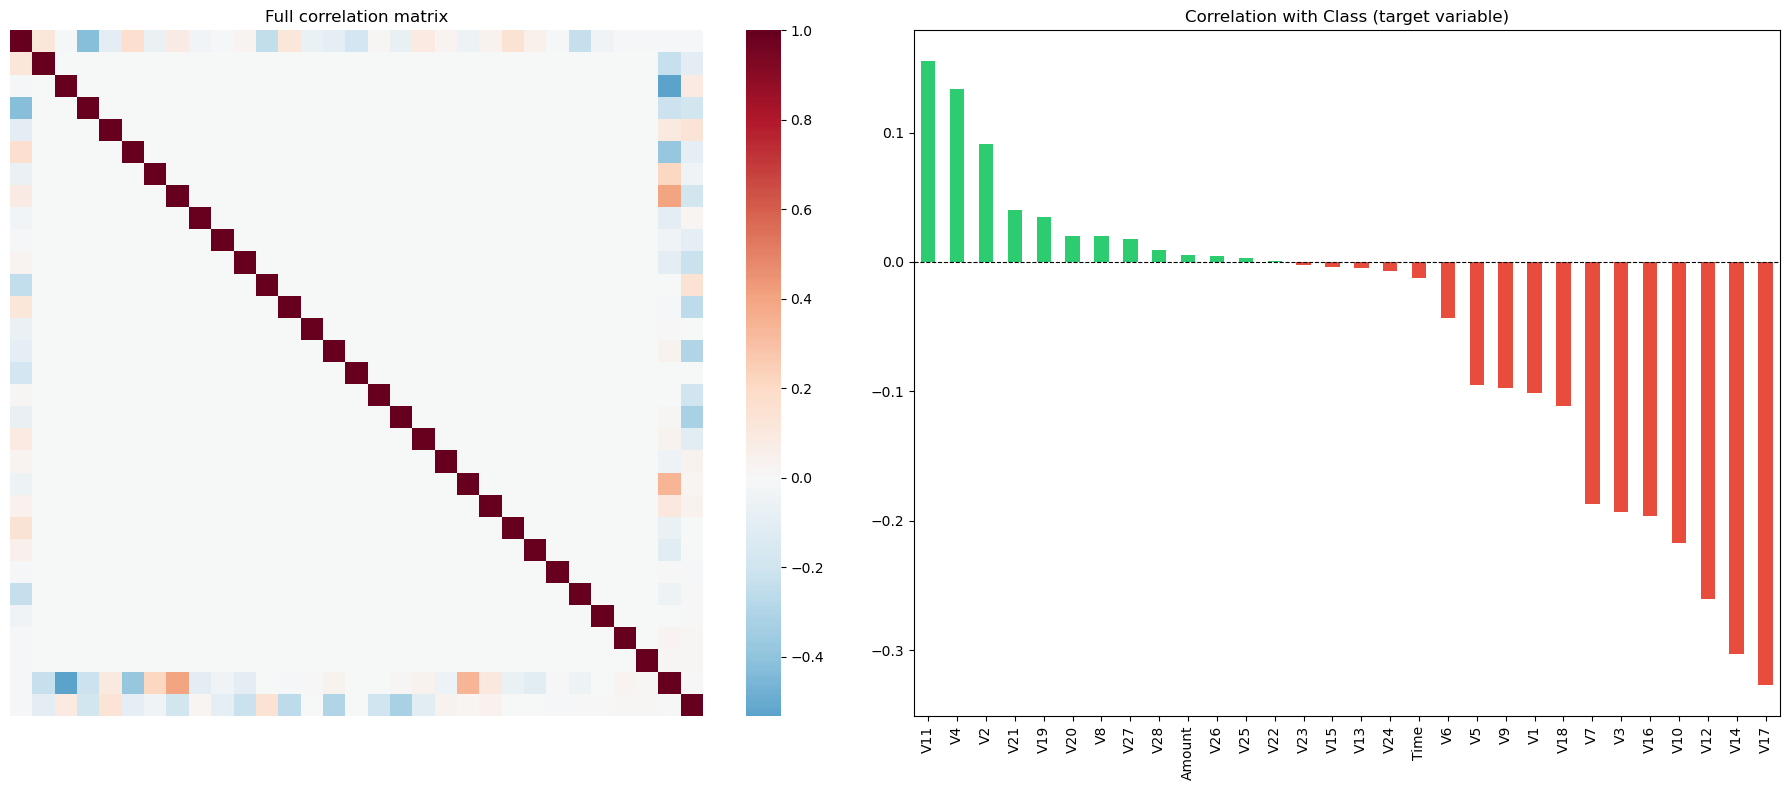

Top 10 features most correlated with fraud:
V17    0.326481
V14    0.302544
V12    0.260593
V10    0.216883
V16    0.196539
V3     0.192961
V7     0.187257
V11    0.154876
V4     0.133447
V18    0.111485
Name: Class, dtype: float64


In [17]:

corr_matrix = df.corr(numeric_only=True)
 
target_corr = corr_matrix['Class'].drop('Class').sort_values(ascending=False)
 
fig, axes = plt.subplots(1, 2, figsize=(18, 8))
 

sns.heatmap(corr_matrix, ax=axes[0], cmap='RdBu_r',
            center=0, xticklabels=False, yticklabels=False)
axes[0].set_title('Full correlation matrix')
 

target_corr.plot(
    kind='bar', ax=axes[1],
    color=['#e74c3c' if v < 0 else '#2ecc71' for v in target_corr]
)
axes[1].set_title('Correlation with Class (target variable)')
axes[1].axhline(y=0, color='black', linestyle='--', linewidth=0.8)
plt.tight_layout()
plt.show()
 

print('Top 10 features most correlated with fraud:')
print(target_corr.abs().sort_values(ascending=False).head(10))


In [18]:
top_6_features = df.corr(numeric_only=True)['Class'].drop('Class').abs().sort_values(ascending=False).head(6).index.tolist()
top_6_features

['V17', 'V14', 'V12', 'V10', 'V16', 'V3']

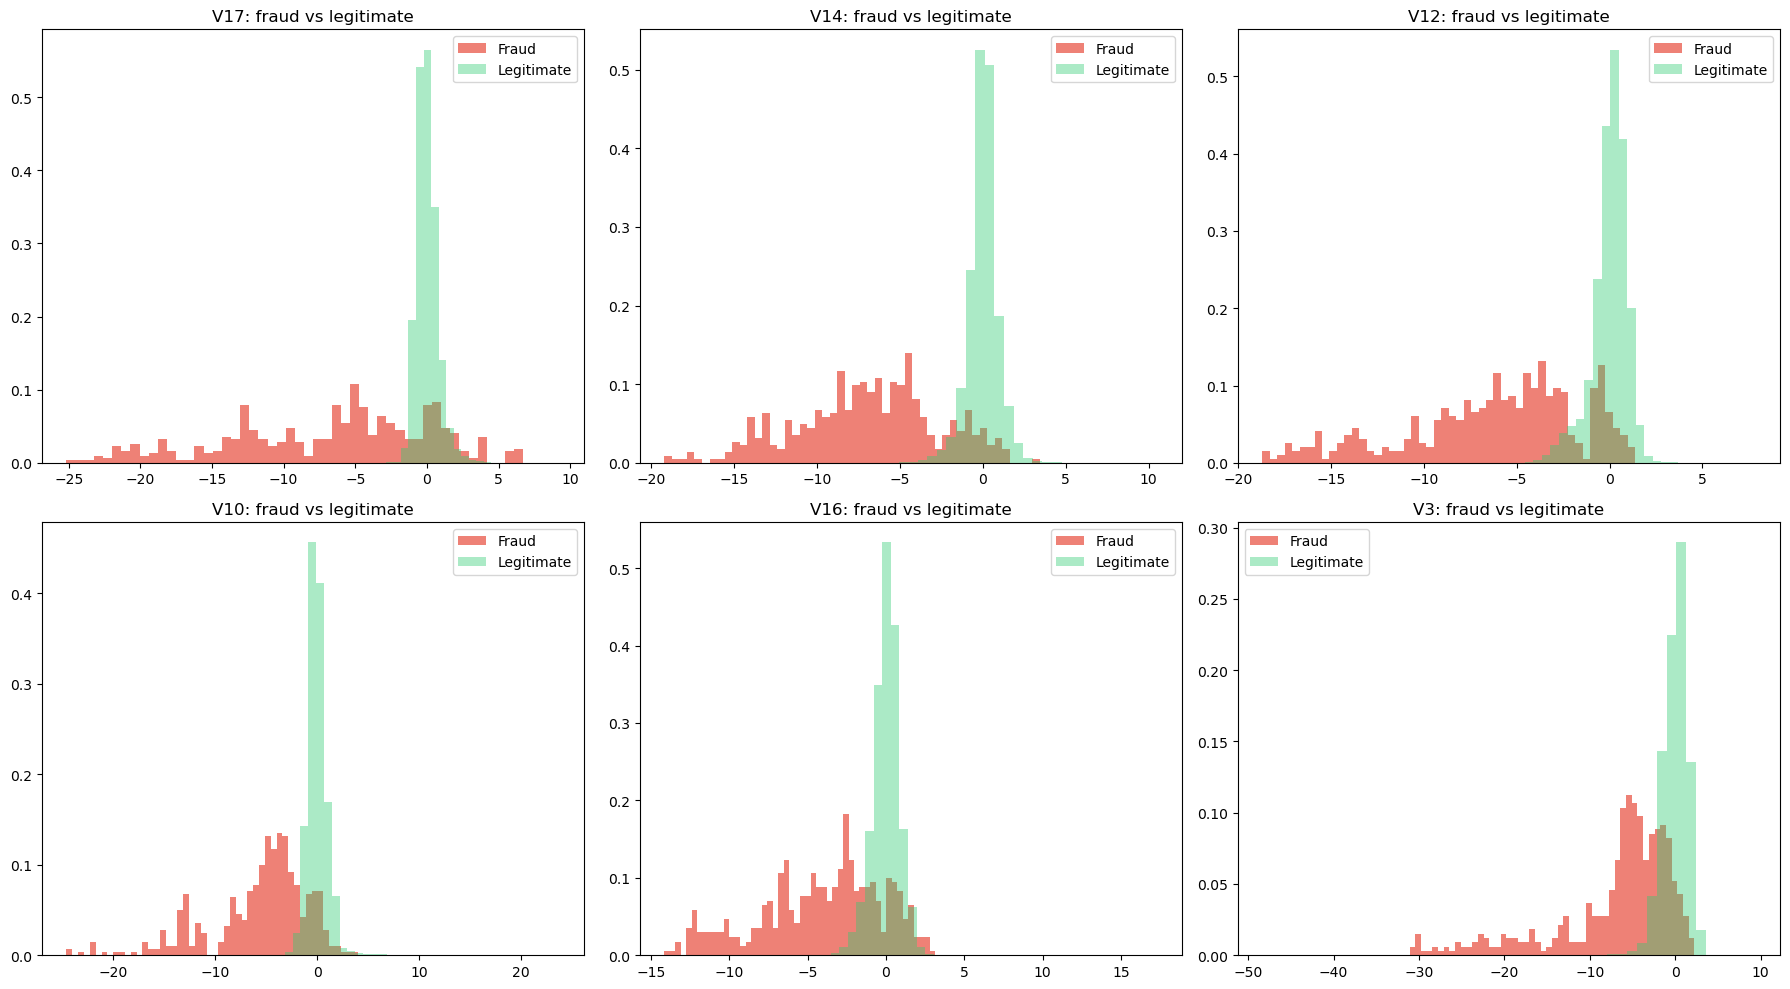

In [21]:
fraud = df[df['Class'] == 1]
legitimate = df[df['Class'] == 0]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, feature in enumerate(top_6_features):
    axes[i].hist(fraud[feature], bins=50, density=True,
                 color='#e74c3c', alpha=0.7, label='Fraud')
    axes[i].hist(legitimate[feature], bins=50, density=True,
                 color='#2ecc71', alpha=0.4, label='Legitimate')
    axes[i].set_title(f'{feature}: fraud vs legitimate')
    axes[i].legend()
plt.tight_layout()
plt.show()

**1. Class Imbalance**
- The dataset has 284807 rows, 31 columns and no null value
- Fraud Transaction: 492, 0.17%
- Legitimate Transaction: 284315, 99.83%

**2. Amount Analysis**
The amount column has the minimum of 0, mean of 88, and the median of 22. This shows a huge gap between the mean and the median which made it to be right skewed.

**3. Time analysis**
Most transactions happened between the hours of 10-20

**4. Most useful features**
The top features according to the top 6 features are ['V17', 'V14', 'V12', 'V10', 'V16', 'V3']

**5. Why we can't train as-is**
- The data is imbalance with 99.83% legitimate and less than 1% fraud. The model will only learn noise and be biase